# TimesFM 2.5 Script

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import torch
import timesfm
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
import random
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

import warnings
warnings.filterwarnings("ignore")

from utils_folder.data_util import *
from utils_folder.timesfm_25_util import *
from utils_folder.plot_util import *

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Critical for CuDNN reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Create folder to store results
BASE_RESULTS_DIR = "results"
SUBFOLDERS = {
    "plain_prediction": "plain_prediction",
    "seasonal_decomposition": "seasonal_decomposition"
}
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

# Create subdirectories
RESULTS_DIRS = {}
for key, folder_name in SUBFOLDERS.items():
    path = os.path.join(BASE_RESULTS_DIR, folder_name)
    os.makedirs(path, exist_ok=True)
    RESULTS_DIRS[key] = path

c:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm_LOCAL_ARCHIVE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Example datasets

In [2]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [False, True]


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, test_raw_aligned=test_raw_series)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"timesfm2_5_results_{date_str}.json"
    else:
        file_name = f"synth_timesfm2_5_results_{date_str}.json"

    output_dir = RESULTS_DIRS["plain_prediction"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1144
Inference time: 84.9790 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1142
Inference time: 90.8245 seconds

Evaluating Case: Context=256, Horizon=8
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1173
Inference time: 86.5411 seconds

Evaluating Case: Context=256, Horizon=16
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1248
Inference time: 71.1104 seconds

Evaluating Case: Context=256, Horizon=24
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1172
Inference time: 90.8416 seconds

Evaluating Case:

[*********************100%***********************]  1 of 1 completed


Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8876
Inference time: 105.0143 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


...


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 3.8091
Inference time: 96.2773 seconds

Evaluating Case: Context=256, Horizon=24
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0



[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 5.0586
Inference time: 81.5413 seconds

Evaluating Case: Context=256, Horizon=32
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


Validation Metrics
RMSE: 6.2340
Inference time: 101.6330 seconds



### Series decomposition

In [2]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [False]
decompose_method = "seasonal"


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method,
                    period="auto"
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method,
                    period="auto"
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, test_raw_aligned=test_raw_series, seasonal_comp=seasonal_comp, train_size=train_size)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"{decompose_method}_metrics_results_{date_str}.json"
    else:
        file_name = f"{decompose_method}_synth_metrics_results_{date_str}.json"

    output_dir = RESULTS_DIRS["seasonal_decomposition"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1348
Inference time: 182.5080 seconds

Evaluating Case: Context=256, Horizon=4
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1337
Inference time: 189.9349 seconds

Evaluating Case: Context=256, Horizon=8
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1360
Inference time: 166.7552 seconds

Evaluating Case: Context=256, Horizon=16
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1448
Inference time: 176.6372 seconds

Evaluating Case: Context=256, Horizon=24
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- U

#### Trend decomposition
The stock market dataset is not defined by any seasonality. Therefore, it is sensible to carry out a decomposition of just its trend by differentiating the series.

In [7]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [True]
decompose_method = "trend_diff"


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, test_raw_aligned=test_raw_series, seasonal_comp=seasonal_comp, train_size=train_size)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"{decompose_method}_metrics_results_{date_str}.json"
    else:
        file_name = f"{decompose_method}_synth_metrics_results_{date_str}.json"

    output_dir = RESULTS_DIRS["seasonal_decomposition"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1


[*********************100%***********************]  1 of 1 completed


Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.8800
Inference time: 156.2578 seconds

Evaluating Case: Context=256, Horizon=4


[*********************100%***********************]  1 of 1 completed


Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


...


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8533
Inference time: 117.9374 seconds

Evaluating Case: Context=256, Horizon=24
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0



[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8652
Inference time: 107.1590 seconds

Evaluating Case: Context=256, Horizon=32


Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.8593
Inference time: 117.9454 seconds



#### Results comparison

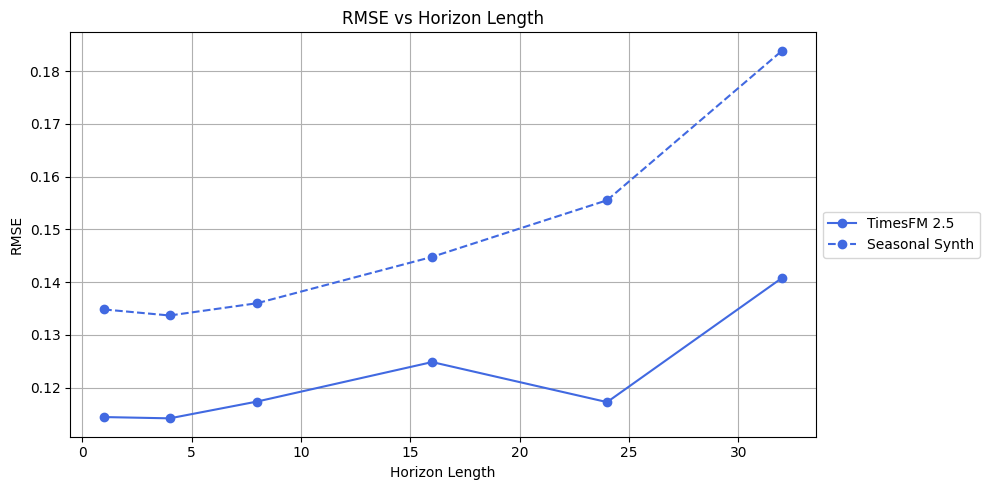

In [2]:
file_paths = [
    "results/plain_prediction/synth_timesfm2_5_results_2026-03-22.json",
    "results/seasonal_decomposition/seasonal_synth_metrics_results_2026-03-23.json"
]
labels = [
    "TimesFM 2.5",
    "Seasonal Synth"
]

linestyles = ['-', '--']

plt.figure(figsize=(10, 5))
for path, label, linestyle in zip(file_paths, labels, linestyles):
    with open(path, 'r') as f:
        data = json.load(f)
    
    horizons = []
    rmses = []
    
    for exp in data["experiments"]:
        horizons.append(exp["horizon"])
        rmses.append(exp["metrics"]["TimesFM 2.5"]["RMSE"])
    
    # Sort by horizon
    horizons, rmses = zip(*sorted(zip(horizons, rmses)))
    
    plt.plot(horizons, rmses, linestyle=linestyle, marker='o', label=label, color="royalblue")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

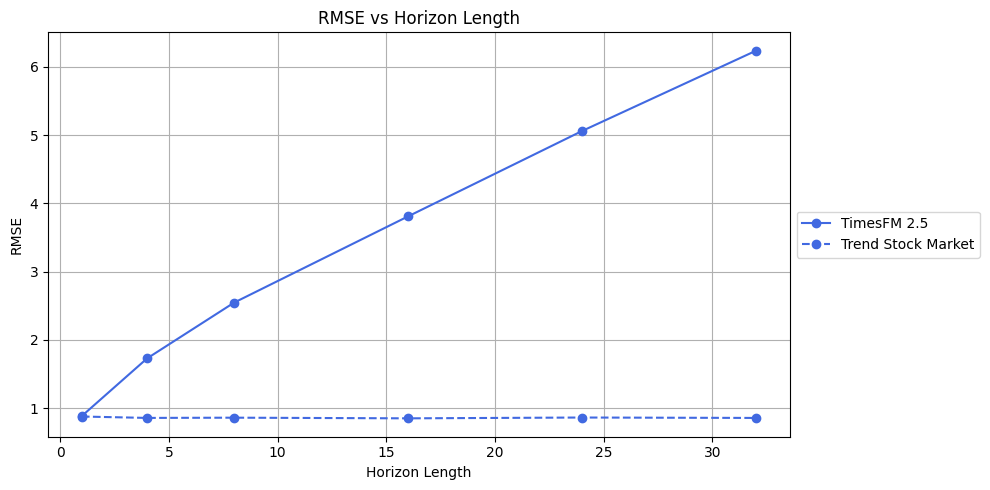

In [3]:
file_paths = [
    "results/plain_prediction/timesfm2_5_results_2026-03-22.json",
    "results/seasonal_decomposition/trend_diff_metrics_results_2026-03-23.json"
]
labels = [
    "TimesFM 2.5",
    "Trend Stock Market"
]

linestyles = ['-', '--']

plt.figure(figsize=(10, 5))
for path, label, linestyle in zip(file_paths, labels, linestyles):
    with open(path, 'r') as f:
        data = json.load(f)
    
    horizons = []
    rmses = []
    
    for exp in data["experiments"]:
        horizons.append(exp["horizon"])
        rmses.append(exp["metrics"]["TimesFM 2.5"]["RMSE"])
    
    # Sort by horizon
    horizons, rmses = zip(*sorted(zip(horizons, rmses)))
    
    plt.plot(horizons, rmses, linestyle=linestyle, marker='o', label=label, color="royalblue")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

### Detailed graphs
#### Synthetic dataset

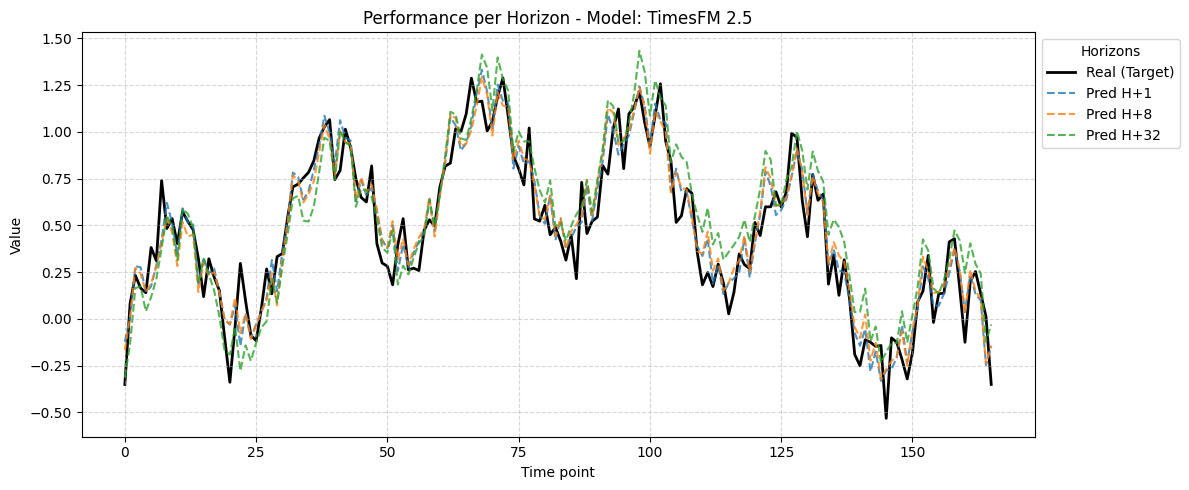

In [4]:
with open('results/seasonal_decomposition/seasonal_synth_metrics_results_2026-03-23.json', 'r') as f:
    data = json.load(f)

df = extract_experiment_data(data)
plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 8, 32])

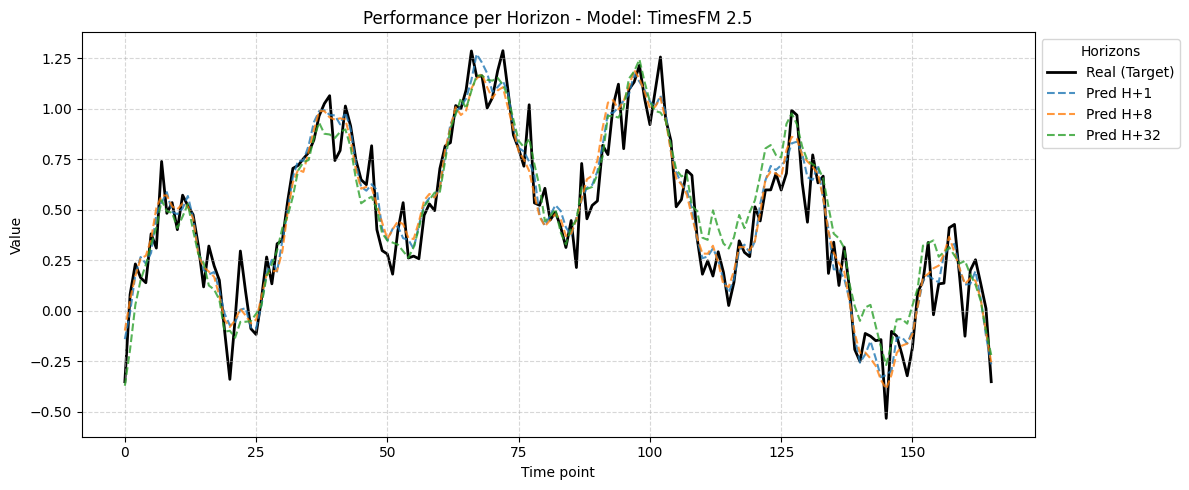

In [45]:
with open('results/plain_prediction/synth_timesfm2_5_results_2026-03-22.json', 'r') as f:
    data = json.load(f)

df = extract_experiment_data(data)
plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 8, 32])

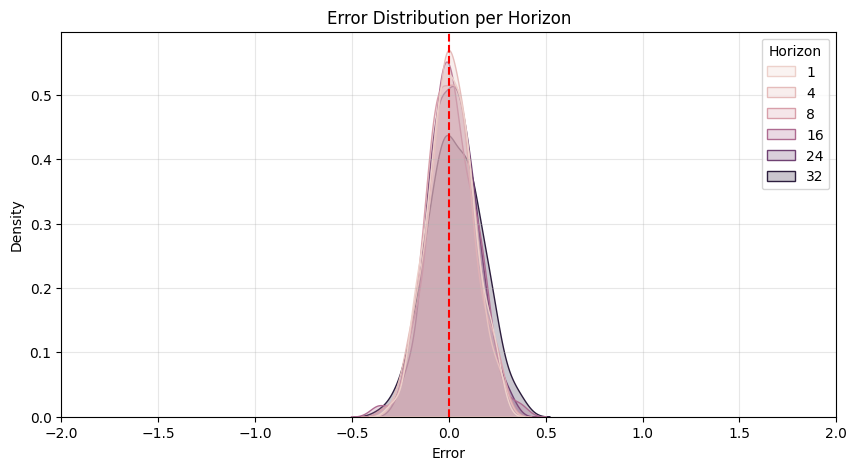

In [46]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="Error", hue="Horizon", fill=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution per Horizon')
plt.xlim([-2.0, 2.0])
plt.grid(True, alpha=0.3)
plt.show()

#### Stock market dataset

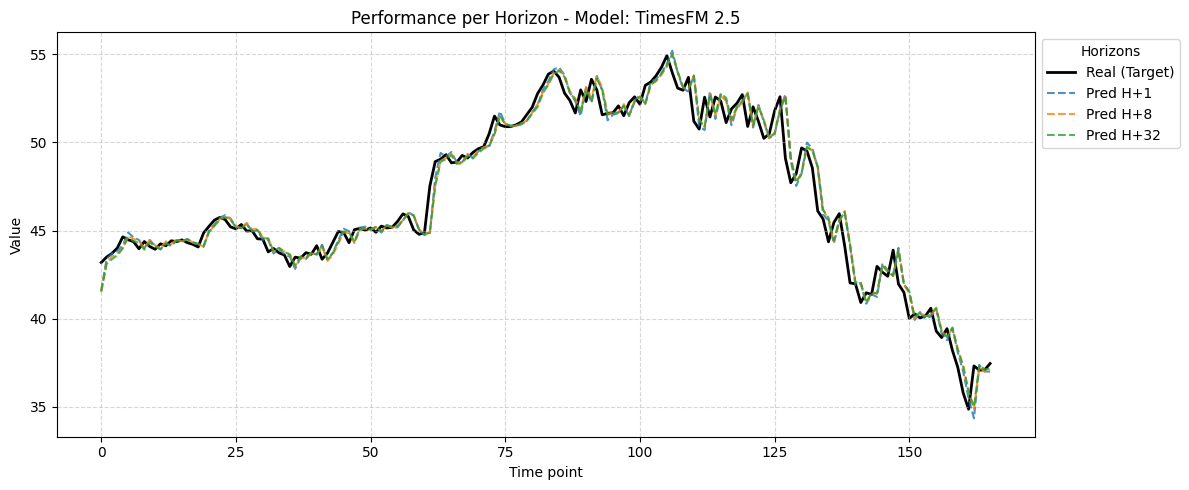

In [10]:
with open('results/seasonal_decomposition/trend_diff_metrics_results_2026-03-23.json', 'r') as f:
    data = json.load(f)

df = extract_experiment_data(data)
plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 8, 32])

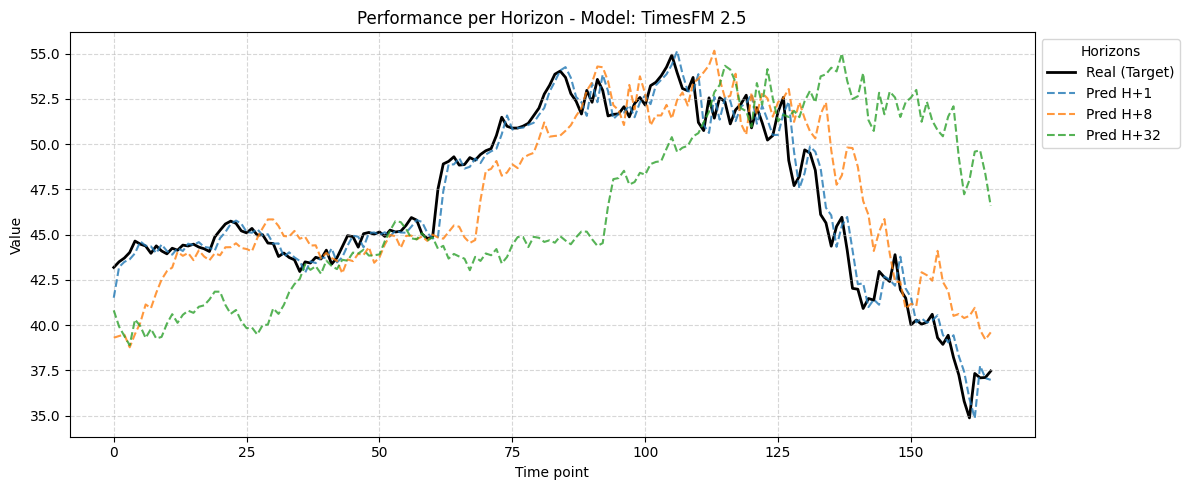

In [47]:
with open('results/plain_prediction/timesfm2_5_results_2026-03-22.json', 'r') as f:
    data = json.load(f)

df = extract_experiment_data(data)
plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 8, 32])

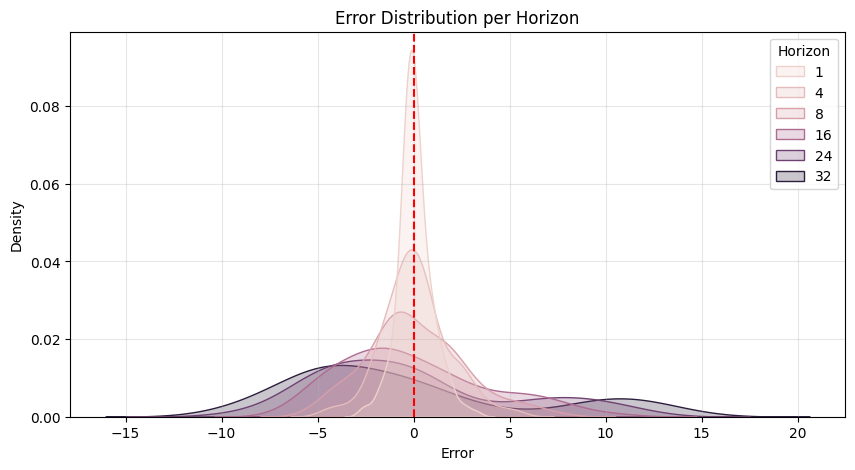

In [48]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="Error", hue="Horizon", fill=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution per Horizon')
plt.grid(True, alpha=0.3)
plt.show()

## Electricity demand
### Daily data

In [13]:
# Define hyperparameters 
context_length = [256]
horizon_length = range(1,8)
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
file_path = 'input_diario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, test_raw_aligned=test_raw_series)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"demand_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["plain_prediction"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 40379.5787
Inference time: 17.9331 seconds

Evaluating Case: Context=256, Horizon=2
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 53426.9614
Inference time: 17.1678 seconds

Evaluating Case: Context=256, Horizon=3
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 59475.8138
Inference time: 13.5225 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 62706.8528
Inference time: 11.6620 seconds

Evaluating Case: Context=256, Horizon=5
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 63877.6446
Inference time: 11.1936 seconds

Evaluati

#### Seasonal decomposition (automatic period detection)

In [11]:
# Define hyperparameters 
context_length = [256]
horizon_length = range(1,8)
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
decompose_method = "seasonal"
file_path = 'input_diario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size, test_raw_series = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type,
                                                                                         decompose=decompose_method,
                                                                                         period="auto"
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, test_raw_aligned=test_raw_series, seasonal_comp=seasonal_comp, train_size=train_size)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"demand_{decompose_method}_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["seasonal_decomposition"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 39160.3705
Inference time: 30.2347 seconds

Evaluating Case: Context=256, Horizon=2
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 52080.0581
Inference time: 19.8709 seconds

Evaluating Case: Context=256, Horizon=3
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 58551.7500
Inference time: 15.0187 seconds

Evaluating Case: Context=256, Horizon=4
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 62108.7752
Inference time: 19.7522 seconds

Evaluating Case: Context=256, Horizon=5
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using 

#### Results comparison

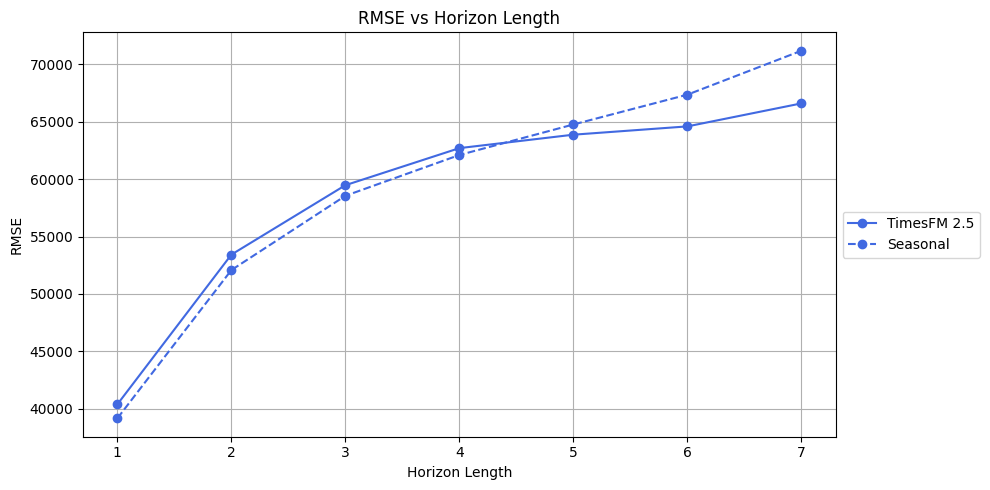

In [4]:
file_paths = [
    "results/plain_prediction/demand_timesfm2_5_results_2026-03-22.json",
    "results/seasonal_decomposition/demand_seasonal_timesfm2_5_results_2026-03-23.json"
]
labels = [
    "TimesFM 2.5",
    "Seasonal"
]

linestyles = ['-', '--']

plt.figure(figsize=(10, 5))
for path, label, linestyle in zip(file_paths, labels, linestyles):
    with open(path, 'r') as f:
        data = json.load(f)
    
    horizons = []
    rmses = []
    
    for exp in data["experiments"]:
        horizons.append(exp["horizon"])
        rmses.append(exp["metrics"]["TimesFM 2.5"]["RMSE"])
    
    # Sort by horizon
    horizons, rmses = zip(*sorted(zip(horizons, rmses)))
    
    plt.plot(horizons, rmses, linestyle=linestyle, marker='o', label=label, color="royalblue")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

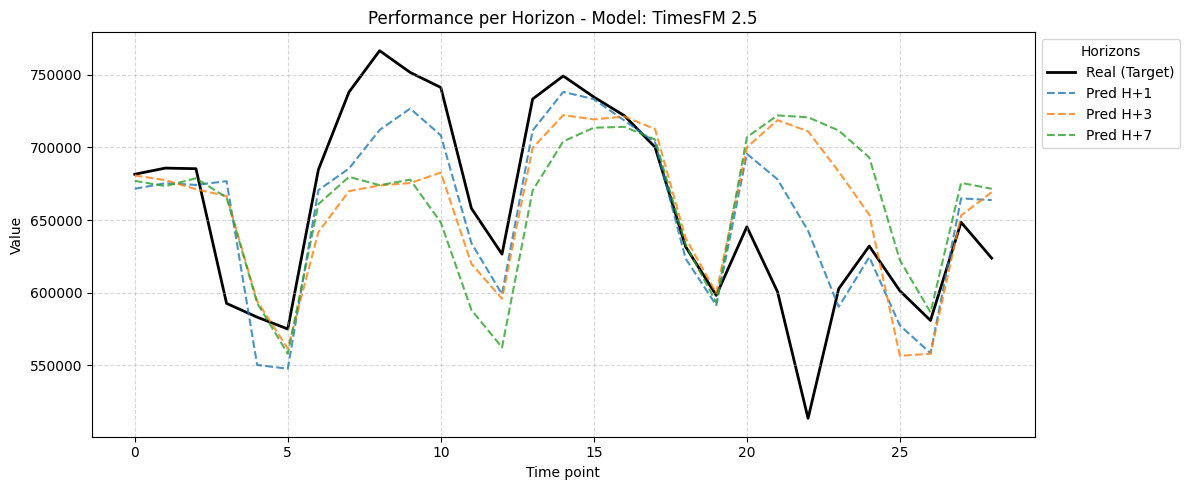

In [42]:
with open('results/plain_prediction/demand_timesfm2_5_results_2026-03-22.json', 'r') as f:
    data = json.load(f)
df = extract_experiment_data(data)

plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 3, 7])

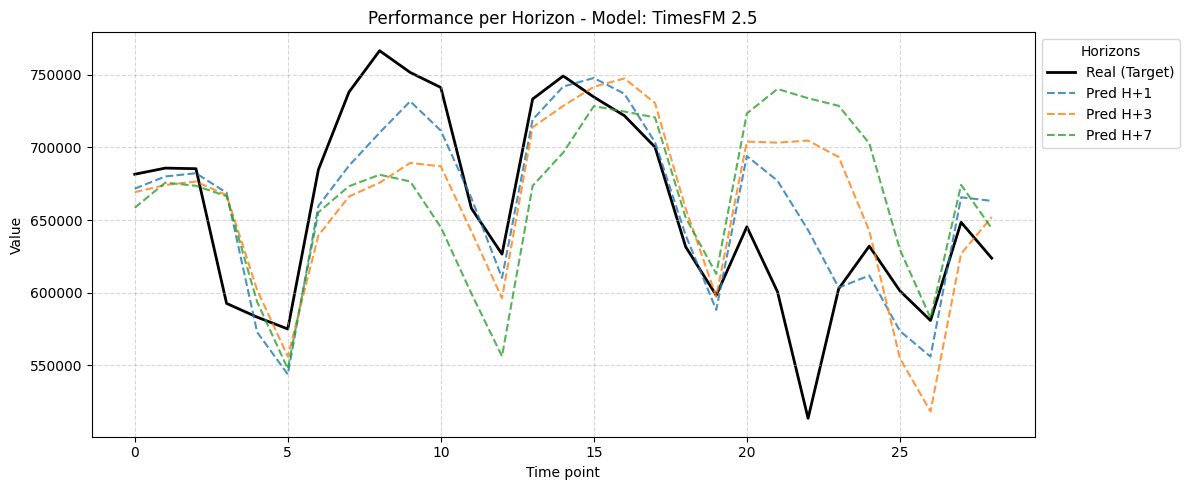

In [14]:
with open('results/seasonal_decomposition/demand_seasonal_timesfm2_5_results_2026-03-23.json', 'r') as f:
    data = json.load(f)
df = extract_experiment_data(data)

plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 3, 7])